## Problem 11.2 - Regression with shallow neural networks from scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [123]:
# define ground truth function
def true_f(x):
    return np.sin(3 * np.pi * x) 

In [124]:
# generating data
np.random.seed(0)
scaler = StandardScaler()
n = 100
sigma = 0.3

X = np.random.uniform(0, 1, n)
X = X.reshape(-1, 1)
X_scaled = scaler.fit_transform(X)

noise = np.random.normal(0, sigma, (n, 1))
y = true_f(X) + noise
y = y.reshape(-1, 1)

In [125]:
# define needed parameters 
max_it = 3000
lamda = 0.001
m = 40
stepsize = 0.05
W1 = np.random.uniform(-1, 1, (m, 1))
b1 = np.random.uniform(-1, 1, (m, 1))
W2 = np.random.uniform(-1, 1, (1, m))
b2 = np.random.uniform(-1, 1, (1, 1))

In [126]:
# define objective function G 
def G(W1, b1, W2, b2):
    z = W1 @ X_scaled.T + b1
    activation = np.tanh(z)
    y_hat = W2 @ activation + b2
    return np.mean((y_hat - y.T)**2) + lamda * (np.sum(W1**2) + np.sum(b1**2) + np.sum(W2**2) + b2**2)

In [127]:
# compute the parts of the gradient
def compute_gradients(W1, b1, W2, b2):
    z = W1 @ X_scaled.T + b1
    activation = np.tanh(z)
    y_hat = W2 @ activation + b2
    error = y_hat - y.T

    dz = (W2.T @ error) * (1 - activation**2)   # inner derivative
    grad_W1 = (2 / n) * dz @ X_scaled + 2 * lamda * W1
    grad_b1 = (2 / n) * np.sum(dz, axis = 1, keepdims = True) + 2 * lamda * b1
    grad_W2 = (2 / n) * error @ activation.T + 2 * lamda * W2
    grad_b2 = (2 / n) * np.sum(error) + 2 * lamda * b2

    return grad_W1, grad_b1, grad_W2, grad_b2
    

In [128]:
# define a function for the whole gradient descent algorithm
def gradient_descent(W1, b1, W2, b2, stepsize, max_it):
    W1_new = W1
    b1_new = b1
    W2_new = W2
    b2_new = b2

    G_values = []
    for iteration in range(max_it):
        G_values.append(G(W1_new, b1_new, W2_new, b2_new).item())
        grad_W1, grad_b1, grad_W2, grad_b2 = compute_gradients(W1, b1, W2, b2)
        W1_new -= stepsize * grad_W1
        b1_new -= stepsize * grad_b1
        W2_new -= stepsize * grad_W2
        b2_new -= stepsize * grad_b2
    return W1_new, b1_new, W2_new, b2_new, G_values

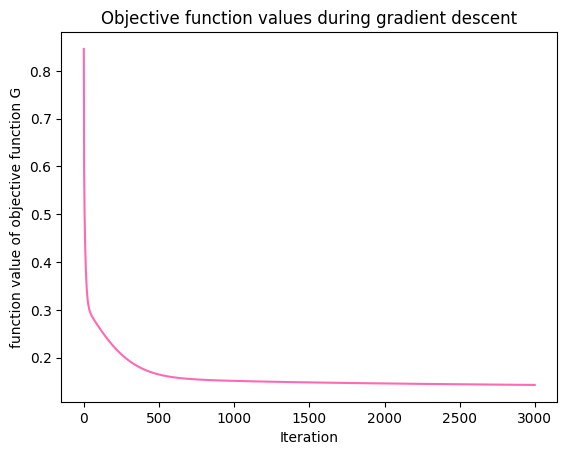

In [129]:
# apply the gradient descent algorithm to our data and plot the objectve function values
W1_opt, b1_opt, W2_opt, b2_opt, G_values = gradient_descent(W1, b1, W2, b2, stepsize, max_it)
plt.figure()
plt.plot(G_values, color = 'hotpink')
plt.xlabel('Iteration')
plt.ylabel('function value of objective function G')
plt.title('Objective function values during gradient descent')
plt.show()

In [142]:
# prediction function using self-implemented gradient descent
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
x_plot_scaled = scaler.transform(x_plot)
activation_pred = np.tanh(W1_opt @ x_plot_scaled.T + b1_opt)
y_pred_grad_descent = (W2_opt @ activation_pred + b2_opt).ravel()

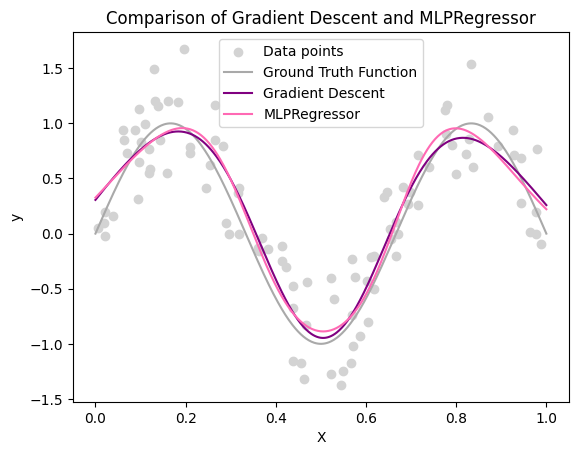

In [147]:
# create MLPRegressor and compare results
mlp = MLPRegressor(hidden_layer_sizes = (m,), activation = 'tanh', alpha = lamda, max_iter = max_it, learning_rate_init = stepsize)
mlp.fit(X_scaled, y.ravel())
y_mlp = mlp.predict(x_plot_scaled)

plt.scatter(X, y, color = 'lightgray', label = 'Data points')
plt.plot(x_plot, true_f(x_plot), color = 'darkgray', label = 'Ground Truth Function')
plt.plot(x_plot, y_pred_grad_descent, color = 'purple', label = 'Gradient Descent')
plt.plot(x_plot, y_mlp, color = 'hotpink', label = 'MLPRegressor')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent and MLPRegressor')
plt.legend()
plt.show()